> 最大奇异值（Singular Value） 或 谱半径（Spectral Radius）。

- todo
    - dnn gradient 分析：bp 时的矩阵连乘

### spectral norm

$W$ 是一个“变形器”。当你把一个向量 $g$（梯度）输入进去，即 $W \cdot g$：
- 如果 $W$ 相当于“乘以 2”，向量 $g$ 就会变长。
- 如果 $W$ 相当于“乘以 0.1”，向量 $g$ 就会缩短。

如果网络有 $L$ 层，梯度反向传播时就像是把向量 $g$ 连续通过 $L$ 个“变形器”：

$$g_{final} = W_1 \cdot W_2 \cdots W_L \cdot g_{initial}$$

如果这些矩阵的“放大倍率”主要都小于 1（例如 0.9），连乘几十次后：$$0.9^{50} \approx 0.005$$向量的长度（梯度的模长）就会趋近于 0，这就是梯度消失。

$$
\|W\|_2 = \max_{x \neq 0} \frac{\|W x\|}{\|x\|}
$$
为了量化这个“放大倍率”（矩阵对向量长度的最大放大倍数），我们使用矩阵范数（Matrix Norm），最常用的是谱范数（Spectral Norm），记作 $\|W\|_2$。它是矩阵 $W$ 的最大奇异值 $\sigma_{max}$。
- 若 $\|W\|_2 < 1$：任意向量被 $W$ 乘过之后，模长都会变小（压缩映射）。
- 若 $\|W\|_2 > 1$：存在某些方向的向量被乘过之后，模长会变大（可能导致梯度爆炸）。

### 特殊的矩阵及其谱范数

假设 $W$ 是一个 $N \times N$ 的矩阵，且 $W_{ij} = c$。这个矩阵是一个秩为 1 的矩阵，它可以写成 $W = c \cdot \mathbf{1}\mathbf{1}^T$（其中 $\mathbf{1}$ 是全 1 的列向量）。
- 对于这种全常数矩阵，其**最大奇异值（谱范数）**的公式为：$$\sigma_{\max} = |c| \cdot N$$
- 秩1矩阵范数：全常数矩阵 $J$ 的最大奇异值确实严格等于 $N \times |c|$。

In [1]:
import torch

# 定义数值大小
c = 0.001

# --- 情况 1: 维度很小 (N=10)，数值全为 0.001 ---
N_small = 10
W_small = torch.full((N_small, N_small), c)
torch.linalg.norm(W_small, ord=2)

/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


tensor(0.0100)

In [2]:
# --- 情况 2: 维度很大 (N=4096)，数值全为 0.001 ---
N_large = 4096
W_large = torch.full((N_large, N_large), c)
torch.linalg.norm(W_large, ord=2)

tensor(4.0960)

In [3]:
# --- 情况 3: 维度很大 (N=4096)，数值是随机的 (标准差=0.001) ---
# 这是为了对比“全常数”和“随机分布”的区别
torch.manual_seed(42)
W_random = torch.randn(N_large, N_large) * c
torch.linalg.norm(W_random, ord=2)

tensor(0.1279)

### 双随机矩阵

- 行和列和均为1，且每个元素都非负
- 谱范数：$\|A\|_2 = 1$
    - 上界证明 (Upper Bound)
        - $\|A\|_2 \le \sqrt{\|A\|_1 \|A\|_\infty}$
            - 行和为 1 $\implies \|A\|_\infty = \max_i \sum_j |a_{ij}| = 1$ (因为 $a_{ij} \ge 0$)
            - 列和为 1 $\implies \|A\|_1 = \max_j \sum_i |a_{ij}| = 1$
        - $\|A\|_2 \le \sqrt{1 \cdot 1} = 1$
    - 下界证明 (Lower Bound)
        - 谱范数的定义是 $\|A\|_2 = \sup_{x \neq 0} \frac{\|Ax\|_2}{\|x\|_2}$。我们只需要找到一个非零向量 $x$，使得 $\frac{\|Ax\|_2}{\|x\|_2} = 1$ 即可证明下界。取全1向量 $\mathbf{1} = [1, 1, \dots, 1]^T$。由于 $A$ 的每一行和为 1，则：$A\mathbf{1} = \mathbf{1}$
        - $\frac{\|A\mathbf{1}\|_2}{\|\mathbf{1}\|_2} = \frac{\|\mathbf{1}\|_2}{\|\mathbf{1}\|_2} = 1$
        - $\|A\|_2 \ge 1$

In [13]:
import torch

def generate_doubly_stochastic_torch(n, batch_size=1, max_iter=100, tol=1e-6, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    使用 Sinkhorn-Knopp 算法生成双随机矩阵 (支持 Batch & GPU)
    """
    # 1. 初始化随机正矩阵 (必须全为正数)
    # 使用 exp 确保元素非负且梯度更稳定
    log_alpha = torch.randn(batch_size, n, n, device=device)
    matrix = torch.exp(log_alpha)
    
    # 2. Sinkhorn 迭代 (交替行归一化和列归一化)
    for _ in range(max_iter):
        # 行归一化
        matrix = matrix / matrix.sum(dim=2, keepdim=True)
        # 列归一化
        matrix = matrix / matrix.sum(dim=1, keepdim=True)
        
        # (可选) 检查收敛性 - 这里为了速度省略，直接迭代固定次数
        
    return matrix

In [14]:
N = 10
# 生成一个 Batch 的双随机矩阵
A_torch = generate_doubly_stochastic_torch(N, batch_size=10)

# 计算谱范数 (ord=2)
spectral_norms = torch.linalg.matrix_norm(A_torch, ord=2)

print(f"Device: {A_torch.device}")
print(f"Shape: {A_torch.shape}")
print(f"Spectral Norms (should be 1):\n{spectral_norms}")
# 验证是否恒等于 1 (允许浮点误差)
print(f"All Close to 1? {torch.allclose(spectral_norms, torch.ones_like(spectral_norms), atol=1e-5)}")

Device: cuda:0
Shape: torch.Size([10, 10, 10])
Spectral Norms (should be 1):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0')
All Close to 1? True


### 深度学习权重矩阵初始化设计

- 我们在初始化神经网络时，绝对不能把权重初始化为固定的常数（比如全 0 或全 0.001），也不能只看元素大小而不看维度。
    - 如果 $W$ 全是 0.001：谱范数问题：如上所述，维度大时会导致梯度爆炸。
    - 对称性问题：所有神经元学到的特征都一样，网络无法通过反向传播学到不同的东西（Symmetry Breaking 问题）。
- 正确的做法（如 Xavier/Kaiming 初始化）：
    - 我们希望权重的方差（或范数）随着维度 $N$ 自动调整。通常我们让 $W_{ij}$ 服从正态分布 $N(0, \sigma^2)$，其中 $\sigma \approx \frac{1}{\sqrt{N}}$。
    - 当元素大小是 $\frac{1}{\sqrt{N}}$ 级别时，矩阵的谱范数保持在 2 附近。
    - 结合 ReLU 

In [6]:
import numpy as np
W_random = torch.randn(N_large, N_large) * 1/np.sqrt(N_large)
torch.linalg.norm(W_random, ord=2)

tensor(1.9983)

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [10]:
# 我们使用标准 He Init: std = sqrt(2/N)
# 这种矩阵的谱范数其实是 > 2 的 (约为 2.8)
layer = nn.Linear(1000, 1000, bias=False)
W = nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
torch.linalg.norm(W, ord=2)

tensor(2.8158, grad_fn=<AmaxBackward0>)

In [11]:
# 设置参数
N = 1000       # 维度
L = 50         # 层数
c = 0.001      # 初始信号强度

# 构造一个谱范数约为 2 的矩阵 (He Initialization: sigma = sqrt(2/N))
# 注意：上一轮我们用 1/sqrt(N) 得到范数~2，实际上 He Init 是 sqrt(2/N)，范数会接近 2.8。
# 为了精准回应你的 "2也会爆炸"，我们这里手动构造一个谱范数严格为 2 的矩阵。
# 方法：用 svd 修改奇异值
torch.manual_seed(42)
W_base = torch.randn(N, N)
U, S, Vh = torch.linalg.svd(W_base, full_matrices=False)
# 强制让所有奇异值都等于 2 (这是一个极端情况，为了演示"由2引起的爆炸")
W_pure_2 = U @ torch.diag(torch.full((N,), 2.0)) @ Vh

# 准备输入数据
x = torch.randn(N)
x = x / torch.norm(x) * c # 归一化并设置初始模长

# --- 实验 A: 纯线性网络 (没有 ReLU) ---
val_linear = x.clone()
norms_linear = []

# --- 实验 B: ReLU 网络 ---
val_relu = x.clone()
norms_relu = []

for i in range(L):
    # 线性层前向传播
    val_linear = W_pure_2 @ val_linear
    norms_linear.append(torch.norm(val_linear).item())
    
    # ReLU 层前向传播
    # 这里我们用正态分布初始化(He init)来模拟真实场景，而不是强制奇异值全为2
    # 因为 ReLU 需要配合随机性才能体现"砍一半"的效果
    # 我们使用标准 He Init: std = sqrt(2/N)
    # 这种矩阵的谱范数其实是 > 2 的 (约为 2.8)
    layer = nn.Linear(N, N, bias=False)
    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    
    if i == 0:
        val_relu = layer(val_relu) # 第一层
    else:
        # 后续层累积
        val_relu = nn.functional.relu(layer(val_relu))
        
    norms_relu.append(torch.norm(val_relu).item())

print(f"层数: {L}")
print(f"线性网络 (谱范数=2) 第50层信号强度: {norms_linear[-1]:.2e}")
print(f"ReLU 网络 (He Init) 第50层信号强度: {norms_relu[-1]:.4f}")

层数: 50
线性网络 (谱范数=2) 第50层信号强度: 1.13e+12
ReLU 网络 (He Init) 第50层信号强度: 0.0008


在神经网络中，我们是在玩一个“加水”和“放水”的平衡游戏：

- 权重矩阵 $W$ 是“加水龙”，它把信号放大（方差 $\times 2$）。
- 激活函数 ReLU 是“放水阀”，它把一半的信号关掉（方差 $\div 2$）。

结论：如果不让矩阵“爆炸”（谱范数 $>1$），加上 ReLU 之后网络就会“干涸”（梯度消失）。正是因为 ReLU 砍得太狠，我们才需要权重矩阵稍微“激进”一点（谱范数 $\approx 2$ 甚至 $\approx 2.8$）来维持生命线。

### Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification

对于一个 $N \times N$ 的方阵 $W$，如果其元素 $W_{ij}$ 独立同分布于均值为 0、方差为 $\sigma^2$ 的高斯分布（即 $W_{ij} \sim \mathcal{N}(0, \sigma^2)$），那么当 $N$ 很大时，其谱范数的期望值为：
$$
\|W\|_2 \approx 2 \cdot \sqrt{N} \cdot \sigma
$$

Dimension (N)   | Theoretical (2*sqrt(N))   | Actual Norm          | Ratio (Actual/Theory)    
------------------------------------------------------------------------------------------
100             | 20.0000                   | 19.9278              | 0.9964                   
500             | 44.7214                   | 44.4267              | 0.9934                   
1000            | 63.2456                   | 62.8928              | 0.9944                   
2000            | 89.4427                   | 89.3597              | 0.9991                   
4096            | 128.0000                  | 127.9199             | 0.9994                   


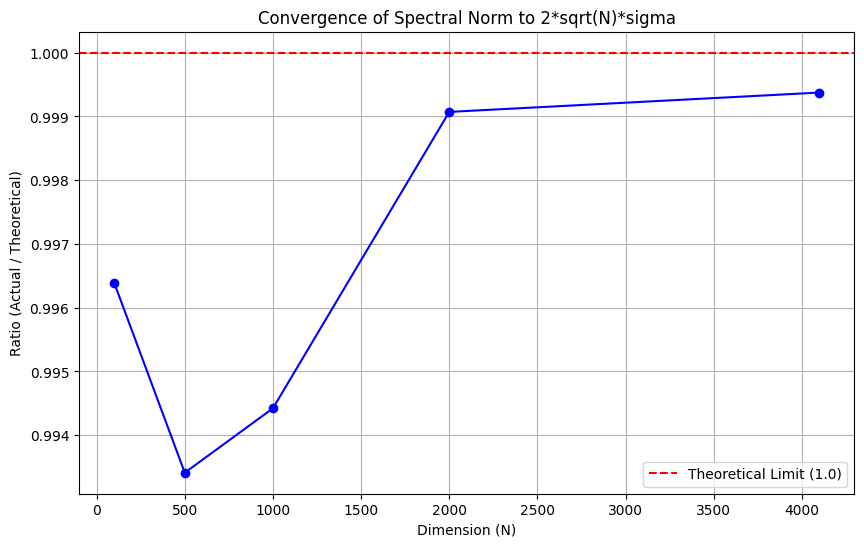

In [12]:
import torch
import math
import matplotlib.pyplot as plt

# Configuration
dimensions = [100, 500, 1000, 2000, 4096]
sigma = 1.0
results = []

print(f"{'Dimension (N)':<15} | {'Theoretical (2*sqrt(N))':<25} | {'Actual Norm':<20} | {'Ratio (Actual/Theory)':<25}")
print("-" * 90)

for N in dimensions:
    # Generate random matrix W ~ N(0, sigma^2)
    # torch.randn generates N(0, 1), so multiply by sigma
    torch.manual_seed(42)  # For reproducibility
    W = torch.randn(N, N) * sigma
    
    # Calculate Spectral Norm (largest singular value)
    actual_norm = torch.linalg.norm(W, ord=2).item()
    
    # Calculate Theoretical Expected Norm: 2 * sqrt(N) * sigma
    theoretical_norm = 2 * math.sqrt(N) * sigma
    
    ratio = actual_norm / theoretical_norm
    results.append((N, actual_norm, theoretical_norm, ratio))
    
    print(f"{N:<15} | {theoretical_norm:<25.4f} | {actual_norm:<20.4f} | {ratio:<25.4f}")

# Plotting
N_vals = [r[0] for r in results]
ratios = [r[3] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(N_vals, ratios, marker='o', linestyle='-', color='b')
plt.axhline(y=1.0, color='r', linestyle='--', label='Theoretical Limit (1.0)')
plt.xlabel('Dimension (N)')
plt.ylabel('Ratio (Actual / Theoretical)')
plt.title('Convergence of Spectral Norm to 2*sqrt(N)*sigma')
plt.grid(True)
plt.legend()

- 提出了 "He Initialization" (Kaiming Init)。
- 数学推导: 论文 explicitly 推导了只要使用了 ReLU，输入信号的方差（Variance）在经过每一层时就会减半（$\frac{1}{2}$）。
- 结论: 为了保持方差不变（Keep the response variance constant），权重的方差必须初始化为 $\frac{2}{n}$，而不是 Xavier 初始化中的 $\frac{1}{n}$。
- 与谱范数的关系: 这篇论文虽然主要讨论“方差”，但方差 $\frac{2}{n}$ 直接导致矩阵的谱范数变大（约为 $\sqrt{2}$ 倍的 Xavier 初始化谱范数），正是这种“放大”抵消了 ReLU 的“损耗”。